# Space-time log-likelihood of rolling catalogs

Scores the observed training catalog, the observed test catalog, and every loaded ETAS and FINE forecast with the space-time point-process log-likelihood. Magnitude is not part of the score.

This is Zhuang et al. (2011), equation 19. Stockman et al., equation 3, is the same expression after `log λ(t, x)` is split into `log λ(t) + log f(x | t)`.

$$
\log L = \sum_i \log \lambda(t_i, x_i, y_i) - \int_{t_0}^{t_1}\int_S \lambda(t, x, y)\,dx\,dy\,dt
$$

`λ` is the ETAS conditional intensity used by these runs: background `μ` plus the Mizrahi triggering kernel. Events in `[t0, t1)` enter the sum. Earlier events in the study region are history. The background integral is `μ` times the study-region area. The triggering integral is the closed-form integral over the whole plane, the same factor the inversion uses for the expected number of offspring.

A **training** score uses that step's fitting window `[train_start, train_end)`. An **observed test** score and each **forecast** score use `[forecast_start, forecast_end)`. Inside a forecast window the synthetic events are part of the history for later synthetic events. The observed score uses the observed events in that role.

Set `HORIZON_DAYS` (default 7), the output root, and optionally a seed list. The plotted distribution is one total per realization: the sum of that seed's window log-likelihoods. The vertical line is the same sum for the observed test windows.


In [12]:
%matplotlib inline
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "etas" / "catalog_loglikelihood.py").is_file():
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    else:
        for parent in REPO_ROOT.parents:
            if (parent / "etas" / "catalog_loglikelihood.py").is_file():
                REPO_ROOT = parent
                break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import etas.catalog_loglikelihood as catalog_loglikelihood
import etas.rolling_analysis as rolling_analysis

# Which forecasts to load.
ROLLING_OUTPUT_ROOT = REPO_ROOT / "outputs/rolling_continuation_hauksson_pre_ridgecrest"
HORIZON_DAYS = 1
METHODS = ["etas", "FINE"]
# None loads every seed that has a catalog for every method on every step.
SEEDS = None
# None scores every step. Set a small integer to try the loader.
MAX_STEPS = None
N_THREADS = 16


def available_horizon_dirs(output_root: Path) -> list[Path]:
    roots = [output_root]
    name = output_root.name
    if name.endswith("_short"):
        roots.append(output_root.with_name(name[: -len("_short")]))
    else:
        roots.append(output_root.with_name(name + "_short"))
    found = []
    for root in roots:
        if not root.is_dir():
            continue
        for path in sorted(root.glob("horizon_*")):
            if path.is_dir() and any(path.glob("step_*")):
                found.append(path)
    return found


def resolve_horizon_dir(output_root: Path, horizon_days: float) -> Path:
    """Pick the horizon folder that actually contains forecast steps.

    The 7, 60, and 300 day walks live under the long pre-Ridgecrest root.
    The 0.5 and 1 day walks live under the ``_short`` root.
    """
    roots = [output_root]
    name = output_root.name
    if name.endswith("_short"):
        roots.append(output_root.with_name(name[: -len("_short")]))
    else:
        roots.append(output_root.with_name(name + "_short"))
    for root in roots:
        horizon_dir = rolling_analysis.horizon_directory(root, horizon_days)
        if horizon_dir.is_dir() and any(horizon_dir.glob("step_*")):
            return horizon_dir
    listing = "\n".join(str(path) for path in available_horizon_dirs(output_root)) or "(none)"
    raise FileNotFoundError(
        f"No step_* catalogs for a {horizon_days:g}-day horizon under {output_root}.\n"
        f"Horizons that do have steps:\n{listing}"
    )


def catalog_path_for(horizon_dir: Path) -> Path:
    step_dir = rolling_analysis._discover_steps(horizon_dir)[0][1]
    config = json.loads((step_dir / "step_config.json").read_text(encoding="utf-8"))
    path = Path(config["fn_catalog"])
    if not path.is_file():
        path = REPO_ROOT / config["fn_catalog"]
    if not path.is_file():
        raise FileNotFoundError(path)
    return path


horizon_dir = resolve_horizon_dir(ROLLING_OUTPUT_ROOT, HORIZON_DAYS)
catalog_path = catalog_path_for(horizon_dir)
display(Markdown(
    f"Horizon directory `{horizon_dir}`\n\n"
    f"Observed catalog `{catalog_path}`"
))


Horizon directory `/home/neriberman/Repos/etas/outputs/rolling_continuation_hauksson_pre_ridgecrest_short/horizon_1d`

Observed catalog `input_data/etas_converted_hauksson.csv`

## Scores

Training uses the auxiliary catalog as history and the fitting window as the target. The test and forecast scores use everything observed before `forecast_start` as history.

The next cell loads `analysis_cache/spacetime_loglikelihood.csv` when the catalog, inversion files, and forecast catalogs are unchanged. A table already written next to the horizon is copied into that cache. Scores are computed only when that table is missing or an input file is newer.


In [13]:
scores = catalog_loglikelihood.load_or_score_rolling_horizon(
    horizon_dir,
    catalog_path,
    methods=METHODS,
    seeds=SEEDS,
    max_steps=MAX_STEPS,
    n_threads=N_THREADS,
    progress=print,
)
scores.groupby("kind").size()


step 0 (1/1134)
step 1 (2/1134)
step 2 (3/1134)
step 3 (4/1134)
step 4 (5/1134)
step 5 (6/1134)
step 6 (7/1134)
step 7 (8/1134)
step 8 (9/1134)
step 9 (10/1134)
step 10 (11/1134)
step 11 (12/1134)
step 12 (13/1134)
step 13 (14/1134)
step 14 (15/1134)
step 15 (16/1134)
step 16 (17/1134)
step 17 (18/1134)
step 18 (19/1134)
step 19 (20/1134)
step 20 (21/1134)
step 21 (22/1134)
step 22 (23/1134)
step 23 (24/1134)
step 24 (25/1134)
step 25 (26/1134)
step 26 (27/1134)
step 27 (28/1134)
step 28 (29/1134)
step 29 (30/1134)
step 30 (31/1134)
step 31 (32/1134)
step 32 (33/1134)
step 33 (34/1134)
step 34 (35/1134)
step 35 (36/1134)
step 36 (37/1134)
step 37 (38/1134)
step 38 (39/1134)
step 39 (40/1134)
step 40 (41/1134)
step 41 (42/1134)
step 42 (43/1134)
step 43 (44/1134)
step 44 (45/1134)
step 45 (46/1134)
step 46 (47/1134)
step 47 (48/1134)
step 48 (49/1134)
step 49 (50/1134)
step 50 (51/1134)
step 51 (52/1134)
step 52 (53/1134)
step 53 (54/1134)
step 54 (55/1134)
step 55 (56/1134)
step 56 (57

kind
forecast         27216
observed_test     1134
training          1134
dtype: int64

## Total log-likelihood

Each forecast total is the sum of that seed's window scores. The observed total is the sum of the observed test windows over the same steps. Training is not on this figure: each training window is the growing fitting catalog, so those values are a different interval.

ETAS and FINE share one histogram. For each method the solid line is the mean, the dotted lines are one standard deviation on either side of the mean, the dashed line is the median, and the dash-dot lines are the 25% and 75% quantiles.


In [14]:
observed = scores[scores["kind"] == "observed_test"]
training = scores[scores["kind"] == "training"]
forecasts = scores[scores["kind"] == "forecast"]

observed_total = float(observed["log_likelihood"].sum())
observed_events = int(observed["n_events"].sum())

totals = (
    forecasts.groupby(["method", "seed"], as_index=False)
    .agg(log_likelihood=("log_likelihood", "sum"), n_events=("n_events", "sum"))
)

rows = []
for method, group in totals.groupby("method"):
    values = group["log_likelihood"].to_numpy(dtype=float)
    rows.append({
        "method": method,
        "n_realizations": int(len(values)),
        "mean_total_logL": float(values.mean()),
        "std_total_logL": float(values.std(ddof=1)) if len(values) > 1 else np.nan,
        "observed_test_logL": observed_total,
        "fraction_realizations_at_or_below_observed": float(np.mean(values <= observed_total)),
        "observed_test_events": observed_events,
        "mean_realization_events": float(group["n_events"].mean()),
    })
summary = pd.DataFrame(rows)
display(summary)

training_view = training[["step_index", "window_start", "window_end", "n_events", "log_likelihood"]].copy()
display(Markdown(
    f"Training log-likelihood on the first step: **{training_view.iloc[0]['log_likelihood']:.1f}** "
    f"({int(training_view.iloc[0]['n_events'])} target events, "
    f"{training_view.iloc[0]['window_start']} to {training_view.iloc[0]['window_end']}). "
    f"On the last step: **{training_view.iloc[-1]['log_likelihood']:.1f}** "
    f"({int(training_view.iloc[-1]['n_events'])} target events)."
))


,method,n_realizations,mean_total_logL,std_total_logL,observed_test_logL,fraction_realizations_at_or_below_observed,observed_test_events,mean_realization_events
0,FINE,12,-18487.801666,17316.848166,-10170.369986,0.666667,1088,3375.833333
1,etas,12,-12336.546720,7649.063093,-10170.369986,0.250000,1088,1348.750000


Training log-likelihood on the first step: **-33758.5** (4851 target events, 2009-02-03 00:00:00 to 2016-05-23 23:05:46). On the last step: **-43917.2** (5939 target events).

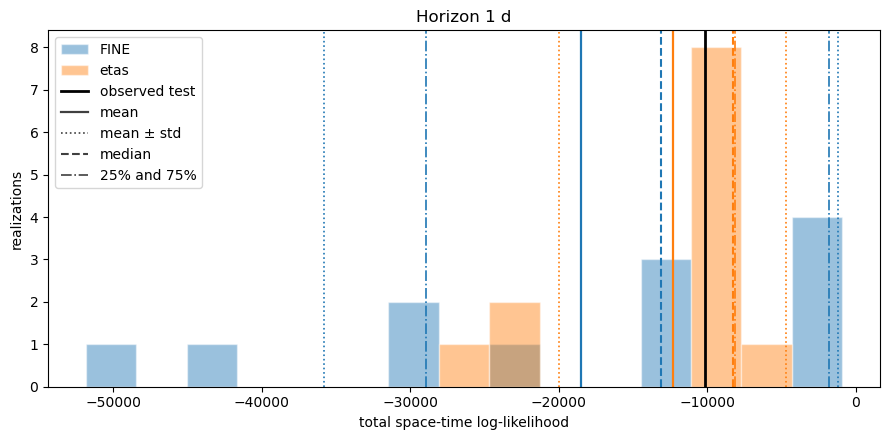

In [15]:
from matplotlib.lines import Line2D

methods = list(totals["method"].unique())
all_values = totals["log_likelihood"].to_numpy(dtype=float)
bins = np.linspace(all_values.min(), all_values.max(), 16)

fig, ax = plt.subplots(figsize=(9, 4.5))
for index, method in enumerate(methods):
    values = totals.loc[totals["method"] == method, "log_likelihood"].to_numpy(dtype=float)
    color = f"C{index}"
    ax.hist(values, bins=bins, color=color, alpha=0.45, edgecolor="white", label=method)
    mean = float(np.mean(values))
    std = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
    median = float(np.median(values))
    q25, q75 = np.quantile(values, [0.25, 0.75])
    ax.axvline(mean, color=color, linestyle="-", linewidth=1.6)
    ax.axvline(mean - std, color=color, linestyle=":", linewidth=1.2)
    ax.axvline(mean + std, color=color, linestyle=":", linewidth=1.2)
    ax.axvline(median, color=color, linestyle="--", linewidth=1.5)
    ax.axvline(q25, color=color, linestyle="-.", linewidth=1.2)
    ax.axvline(q75, color=color, linestyle="-.", linewidth=1.2)

ax.axvline(observed_total, color="black", linewidth=2, label="observed test")
handles, labels = ax.get_legend_handles_labels()
handles += [
    Line2D([0], [0], color="0.25", linestyle="-", linewidth=1.6, label="mean"),
    Line2D([0], [0], color="0.25", linestyle=":", linewidth=1.2, label="mean ± std"),
    Line2D([0], [0], color="0.25", linestyle="--", linewidth=1.5, label="median"),
    Line2D([0], [0], color="0.25", linestyle="-.", linewidth=1.2, label="25% and 75%"),
]
ax.legend(handles=handles, loc="upper left")
ax.set_xlabel("total space-time log-likelihood")
ax.set_ylabel("realizations")
ax.set_title(f"Horizon {HORIZON_DAYS:g} d")
fig.tight_layout()
plt.show()


## Each forecast window

The band is the 2.5%–97.5% range of the loaded realizations in that window. The black line is the observed test catalog in the same window. The lower panel is the training-window log-likelihood under that step's parameters. It uses a much longer interval than the forecast, and the interval grows as the walk moves forward.


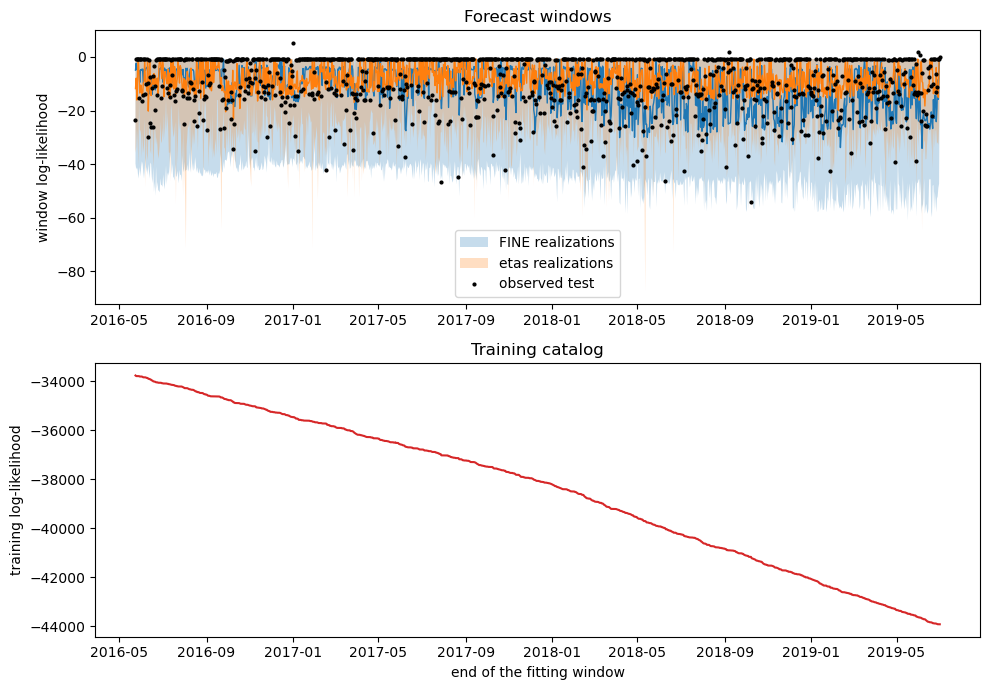

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

for method in methods:
    frame = forecasts[forecasts["method"] == method]
    grouped = frame.groupby("step_index")
    starts = grouped["window_start"].min()
    low = grouped["log_likelihood"].quantile(0.025)
    high = grouped["log_likelihood"].quantile(0.975)
    mid = grouped["log_likelihood"].median()
    axes[0].fill_between(starts, low, high, alpha=0.25, label=f"{method} realizations")
    axes[0].plot(starts, mid, linewidth=1)
axes[0].plot(observed["window_start"], observed["log_likelihood"], color="black", marker="o", markersize=2, linestyle="none", label="observed test")
axes[0].set_ylabel("window log-likelihood")
axes[0].legend()
axes[0].set_title("Forecast windows")

axes[1].plot(training["window_end"], training["log_likelihood"], color="C3")
axes[1].set_ylabel("training log-likelihood")
axes[1].set_xlabel("end of the fitting window")
axes[1].set_title("Training catalog")
fig.tight_layout()
plt.show()
